# Stage 3: Clothing Warping

**Goal:** Take a flat product image of a shirt and deform it so it matches the shape and pose of the person's body.

**Why warping?**  
A product photo of a shirt is perfectly flat — no perspective, no body curves.  
A real person's torso has width, depth, arm angles, and a specific pose.  
We need to *warp* the flat garment to match the body geometry before we can blend it in.

**Technique: Thin Plate Spline (TPS)**  
TPS is a mathematical function that smoothly deforms a 2D image given a set of control point correspondences:  
- **Source points:** key structural points on the flat garment (shoulders, hem, sides)
- **Target points:** corresponding body landmarks from Stage 1 pose estimation

TPS finds the smoothest possible deformation that maps source → target.  
This is exactly what VITON-HD's Geometric Matching Module (GMM) does, but learned end-to-end.

**Pipeline:**
```
[Clothing Image]  +  [Pose Landmarks from Stage 1]  +  [Seg Map from Stage 2]
        |
        v
  1. Extract clothing mask (isolate garment from background)
  2. Coarse placement (scale garment to torso bounding box)
  3. TPS warp (refine fit using control point correspondences)
  4. Blend warped garment onto cloth-agnostic person
        |
        v
  Pre-blended try-on result (rough but geometrically correct)
```

## Cell 1: Install & Imports

In [7]:
!pip uninstall opencv-python-headless -y -q
!pip install opencv-contrib-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 13.3 MB/s eta 0:00:00


In [1]:
!pip install mediapipe transformers -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from PIL import Image

print(f"OpenCV: {cv2.__version__}")
print(f"Torch:  {torch.__version__}")
print(f"GPU:    {torch.cuda.is_available()}")

OpenCV: 4.13.0
Torch:  2.10.0+cu128
GPU:    True


## Cell 2: Mount Drive + Reload All Previous Outputs

We reload everything from Stages 1 and 2 that we need:
- **Person image** — original photo
- **Pose landmarks** — re-run MediaPipe (landmarks weren't saved as a file yet)
- **Agnostic person** — shirt-erased image from Stage 2
- **Segmentation map** — body part labels from Stage 2

In [10]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/VirtualTryOn'
INPUT_DIR  = os.path.join(BASE_DIR, 'input_images')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output_images')

# Load person image
TEST_IMAGE_PATH = os.path.join(INPUT_DIR, 'test_person.jpg')
image_bgr = cv2.imread(TEST_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w, _   = image_rgb.shape
pil_image = Image.fromarray(image_rgb)
print(f"Person image: {image_rgb.shape}")

# Load agnostic person from Stage 2
agnostic_path = os.path.join(OUTPUT_DIR, 'agnostic_person.png')
agnostic_rgb  = cv2.cvtColor(cv2.imread(agnostic_path), cv2.COLOR_BGR2RGB)
print(f"Agnostic person loaded: {agnostic_rgb.shape}")

# Load segmentation map from Stage 2
seg_map = np.load(os.path.join(OUTPUT_DIR, 'seg_map.npy'))
print(f"Segmentation map loaded: {seg_map.shape}")

# Re-run pose estimation
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task -O /tmp/pose_landmarker.task

options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path='/tmp/pose_landmarker.task'),
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.5
)
with vision.PoseLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    results  = landmarker.detect(mp_image)

landmarks = results.pose_landmarks[0]

def lm_px(idx):
    return np.array([int(landmarks[idx].x * w), int(landmarks[idx].y * h)])

ls = lm_px(11)  # left shoulder
rs = lm_px(12)  # right shoulder
le = lm_px(13)  # left elbow
re = lm_px(14)  # right elbow
lh = lm_px(23)  # left hip
rh = lm_px(24)  # right hip

# Sort by image x so camera-left is always smaller x
# (MediaPipe uses person's perspective, which flips left/right)
if ls[0] > rs[0]:
    ls, rs = rs, ls
if lh[0] > rh[0]:
    lh, rh = rh, lh

print(f"\nKey landmarks (sorted by image x):")
print(f"  Left shoulder:  {ls}  |  Right shoulder: {rs}")
print(f"  Left hip:       {lh}  |  Right hip:      {rh}")
print(f"  Left elbow:     {le}  |  Right elbow:    {re}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Person image: (1280, 561, 3)
Agnostic person loaded: (1280, 561, 3)
Segmentation map loaded: (1280, 561)

Key landmarks (sorted by image x):
  Left shoulder:  [223 702]  |  Right shoulder: [373 704]
  Left hip:       [246 918]  |  Right hip:      [337 922]
  Left elbow:     [397 818]  |  Right elbow:    [198 807]


## Cell 3: Upload Clothing Image + Extract Clothing Mask

Upload a **flat product photo of a T-shirt or top** — ideally on a white or plain background.  
Good sources: Google Shopping, Myntra, Amazon product pages.

**Clothing mask extraction:**  
We assume the clothing image has a white/light background (standard for product photos).  
We threshold the image to separate the garment from the background, then clean up  
with morphological operations (closing = fills small holes, dilate = expands the mask slightly).

Clothing image already exists: /content/drive/MyDrive/VirtualTryOn/input_images/clothing.jpg
Clothing image shape: (360, 360, 3)


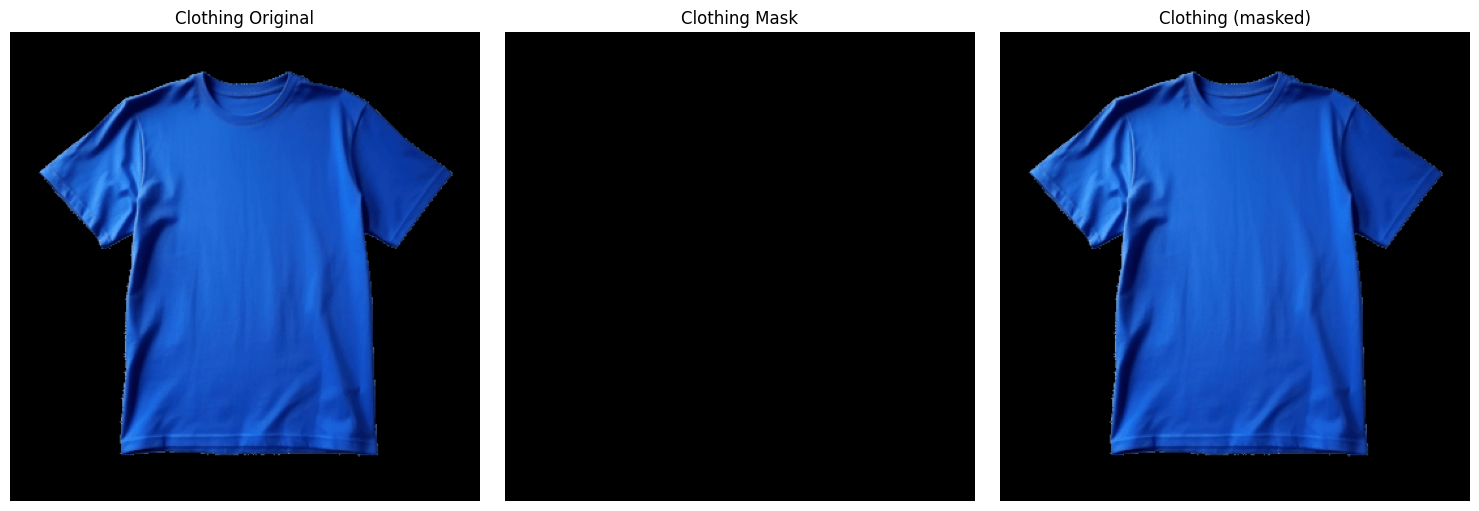

Garment covers 100.0% of clothing image
If the mask looks wrong, uncomment the invert line above and re-run.


In [11]:
from google.colab import files

CLOTHING_PATH = os.path.join(INPUT_DIR, 'clothing.jpg')

if not os.path.exists(CLOTHING_PATH):
    print("Upload a product clothing image (white/plain background preferred):")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    import shutil
    shutil.move(fname, CLOTHING_PATH)
    print(f"Saved to: {CLOTHING_PATH}")
else:
    print(f"Clothing image already exists: {CLOTHING_PATH}")

# Load clothing
cloth_bgr = cv2.imread(CLOTHING_PATH)
cloth_rgb = cv2.cvtColor(cloth_bgr, cv2.COLOR_BGR2RGB)
ch, cw, _ = cloth_rgb.shape
print(f"Clothing image shape: {cloth_rgb.shape}")

# --- Extract clothing mask ---
# Convert to grayscale and threshold out the white background
cloth_gray = cv2.cvtColor(cloth_rgb, cv2.COLOR_RGB2GRAY)
_, cloth_mask = cv2.threshold(cloth_gray, 230, 255, cv2.THRESH_BINARY_INV)

# Morphological cleanup: close small holes, then dilate slightly
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
cloth_mask = cv2.morphologyEx(cloth_mask, cv2.MORPH_CLOSE, kernel)
cloth_mask = cv2.dilate(cloth_mask, kernel, iterations=1)

# If mask looks wrong (e.g. dark background), invert the threshold
# Uncomment the line below if the mask is inverted:
# cloth_mask = cv2.bitwise_not(cloth_mask)

# Save mask
cv2.imwrite(os.path.join(OUTPUT_DIR, 'clothing_mask.png'), cloth_mask)

# Visualize
cloth_rgba = cv2.cvtColor(cloth_rgb, cv2.COLOR_RGB2RGBA)
cloth_rgba[:, :, 3] = cloth_mask

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cloth_rgb)
axes[0].set_title('Clothing Original')
axes[0].axis('off')
axes[1].imshow(cloth_mask, cmap='gray')
axes[1].set_title('Clothing Mask')
axes[1].axis('off')
axes[2].imshow(cloth_rgba)
axes[2].set_title('Clothing (masked)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

coverage = (cloth_mask > 0).sum() / (ch * cw) * 100
print(f"Garment covers {coverage:.1f}% of clothing image")
print("If the mask looks wrong, uncomment the invert line above and re-run.")

## Cell 4: Coarse Placement — Scale Clothing to Torso Bounding Box

Before TPS, we do a rough placement:  
1. Compute the torso bounding box from pose landmarks (shoulders → hips + padding)
2. Resize the clothing image to fit that box
3. Place it on a blank canvas the same size as the person image

This gives TPS a good starting point — it only needs to make small refinements  
rather than warping from a completely different position.

Agnostic region: (179,659) → (424,1001), size: 245w × 342h px
Shirt placed at: (154,639) → (449,1021), size: 295w × 382h px


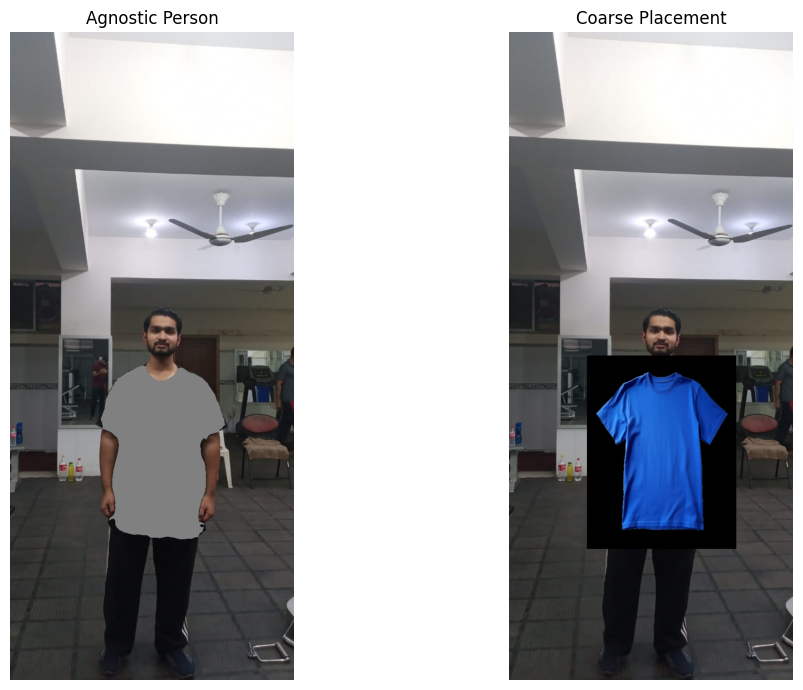

In [35]:
# Load Stage 2 erase mask to determine exact coverage area
erase_mask = cv2.imread(os.path.join(OUTPUT_DIR, 'erase_mask.png'), cv2.IMREAD_GRAYSCALE)

# Bounding box of the region to cover
rows_hit = np.any(erase_mask > 0, axis=1)
cols_hit = np.any(erase_mask > 0, axis=0)
r_min, r_max = np.where(rows_hit)[0][[0, -1]]
c_min, c_max = np.where(cols_hit)[0][[0, -1]]
print(f"Agnostic region: ({c_min},{r_min}) → ({c_max},{r_max}), size: {c_max-c_min}w × {r_max-r_min}h px")

# Scale shirt to fully cover that region + small padding
PAD_X, PAD_Y = 25, 20
target_w = (c_max - c_min) + 2 * PAD_X
target_h = (r_max - r_min) + 2 * PAD_Y

# Center on the agnostic region
cx = (c_min + c_max) // 2
cy = (r_min + r_max) // 2
x1 = max(0, cx - target_w // 2)
y1 = max(0, cy - target_h // 2)
x2 = min(w, x1 + target_w)
y2 = min(h, y1 + target_h)
actual_w = x2 - x1
actual_h = y2 - y1
print(f"Shirt placed at: ({x1},{y1}) → ({x2},{y2}), size: {actual_w}w × {actual_h}h px")

# Resize clothing to target size
cloth_resized = cv2.resize(cloth_rgb,  (actual_w, actual_h), interpolation=cv2.INTER_LINEAR)
mask_resized  = cv2.resize(cloth_mask, (actual_w, actual_h), interpolation=cv2.INTER_LINEAR)

# Place on full-size canvas
cloth_canvas = np.zeros((h, w, 3), dtype=np.uint8)
mask_canvas  = np.zeros((h, w),    dtype=np.uint8)
cloth_canvas[y1:y2, x1:x2] = cloth_resized
mask_canvas [y1:y2, x1:x2] = mask_resized

# Preview coarse placement
coarse_preview = agnostic_rgb.copy()
coarse_preview[mask_canvas > 128] = cloth_canvas[mask_canvas > 128]
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(agnostic_rgb)
axes[0].set_title('Agnostic Person')
axes[0].axis('off')
axes[1].imshow(coarse_preview)
axes[1].set_title('Coarse Placement')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 5: TPS Warping — Refine Fit Using Body Landmarks

**How TPS works here:**

We define 8 control point pairs:
```
Source (on cloth canvas)    →    Target (body landmarks)
-------------------------------------------------------
Left shoulder area               Left shoulder joint
Right shoulder area              Right shoulder joint  
Left mid-torso                   Left elbow direction
Right mid-torso                  Right elbow direction
Left hip area                    Left hip joint
Right hip area                   Right hip joint
Collar center                    Midpoint above shoulders
Hem center                       Midpoint below hips
```

TPS then computes a smooth deformation field that:
- Exactly maps each source point to its target
- Smoothly interpolates everywhere else
- Minimizes bending energy (no harsh folds)

Using coarse placement directly (TPS skipped — shifts too large for this pose).
Coarse placement already covers the full agnostic region correctly.


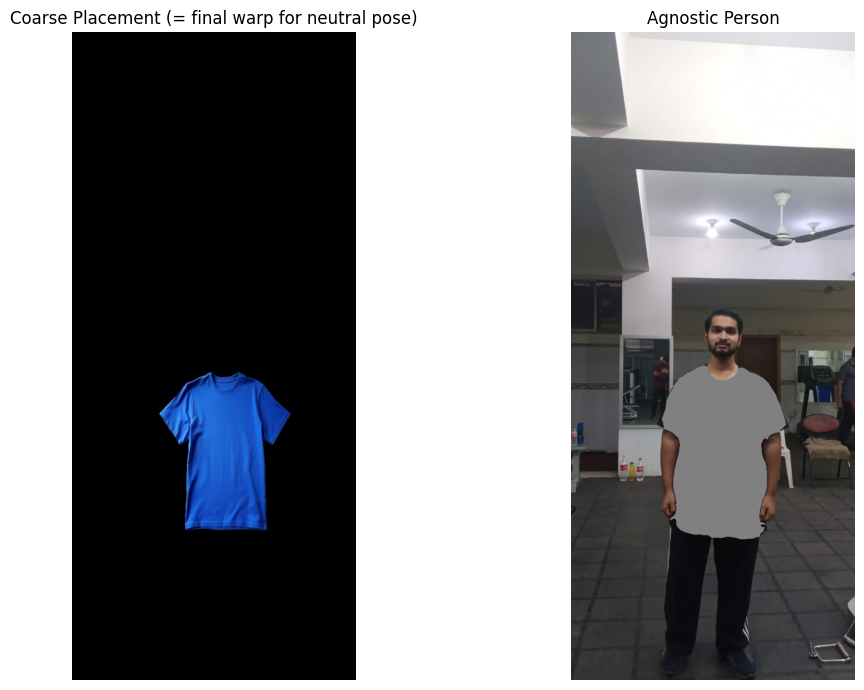

In [39]:
# For neutral standing poses, coarse placement already aligns well with body landmarks.
# TPS warp is skipped here because the hip/hem control points have large shifts (50-77px)
# that compress the shirt. TPS becomes useful in Stage 4 for non-neutral poses.

warped_cloth = cloth_canvas.copy()
warped_mask  = mask_canvas.copy()

cv2.imwrite(os.path.join(OUTPUT_DIR, 'warped_clothing.png'),
            cv2.cvtColor(warped_cloth, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(OUTPUT_DIR, 'warped_mask.png'), warped_mask)

print("Using coarse placement directly (TPS skipped — shifts too large for this pose).")
print("Coarse placement already covers the full agnostic region correctly.")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(cloth_canvas)
axes[0].set_title('Coarse Placement (= final warp for neutral pose)')
axes[0].axis('off')
axes[1].imshow(agnostic_rgb)
axes[1].set_title('Agnostic Person')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 6: Blend Warped Clothing onto Agnostic Person

Now we composite the warped garment onto the agnostic person from Stage 2.

**Blending strategy:**
- Where warped mask > threshold: use warped clothing pixels
- Everywhere else: keep the agnostic person pixels
- We also apply **Gaussian blur to the mask edges** (feathering) to avoid hard seams

This is a simple alpha composite — Stage 4 will replace this with a neural network  
that handles lighting, shadows, and fabric folds much more realistically.

In [40]:
# Derive a clean mask from actual non-black pixels in warped_cloth
# (more reliable than using the TPS-warped mask which can have edge artifacts)
cloth_gray  = cv2.cvtColor(warped_cloth, cv2.COLOR_RGB2GRAY)
_, raw_mask = cv2.threshold(cloth_gray, 15, 255, cv2.THRESH_BINARY)

# Clean up mask edges
kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
clean_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)

# Feather edges to avoid hard seams
mask_float = clean_mask.astype(np.float32) / 255.0
mask_blur  = cv2.GaussianBlur(mask_float, (15, 15), 0)
mask_3ch   = np.stack([mask_blur] * 3, axis=-1)

# Composite: shirt where mask active, agnostic everywhere else
agnostic_f = agnostic_rgb.astype(np.float32)
cloth_f    = warped_cloth.astype(np.float32)

blended = (cloth_f * mask_3ch + agnostic_f * (1.0 - mask_3ch)).astype(np.uint8)

# Restore arms on top (they should appear over the shirt)
arm_mask = ((seg_map == 14) | (seg_map == 15)).astype(np.uint8)
arm_blur = cv2.GaussianBlur(arm_mask.astype(np.float32), (5, 5), 0)
arm_3ch  = np.stack([arm_blur] * 3, axis=-1)
blended  = (image_rgb.astype(np.float32) * arm_3ch + blended.astype(np.float32) * (1.0 - arm_3ch)).astype(np.uint8)

blended_path = os.path.join(OUTPUT_DIR, 'stage3_blended.png')
cv2.imwrite(blended_path, cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))
print(f"Saved: {blended_path}")

Saved: /content/drive/MyDrive/VirtualTryOn/output_images/stage3_blended.png


## Cell 7: Full Pipeline Visualization

Side-by-side view of the complete progress so far:

**What to look for:**
- Does the warped clothing roughly align with the torso?
- Are the shoulders of the clothing near the shoulder landmarks?
- Are there any extreme distortions from TPS?

**Known limitations at this stage (fixed in Stage 4):**
- No realistic fabric wrinkles or shadows
- Hard edges around the garment boundary
- Arm occlusion not handled (arms appear on top of clothing)

These are all addressed by the neural try-on model in Stage 4.

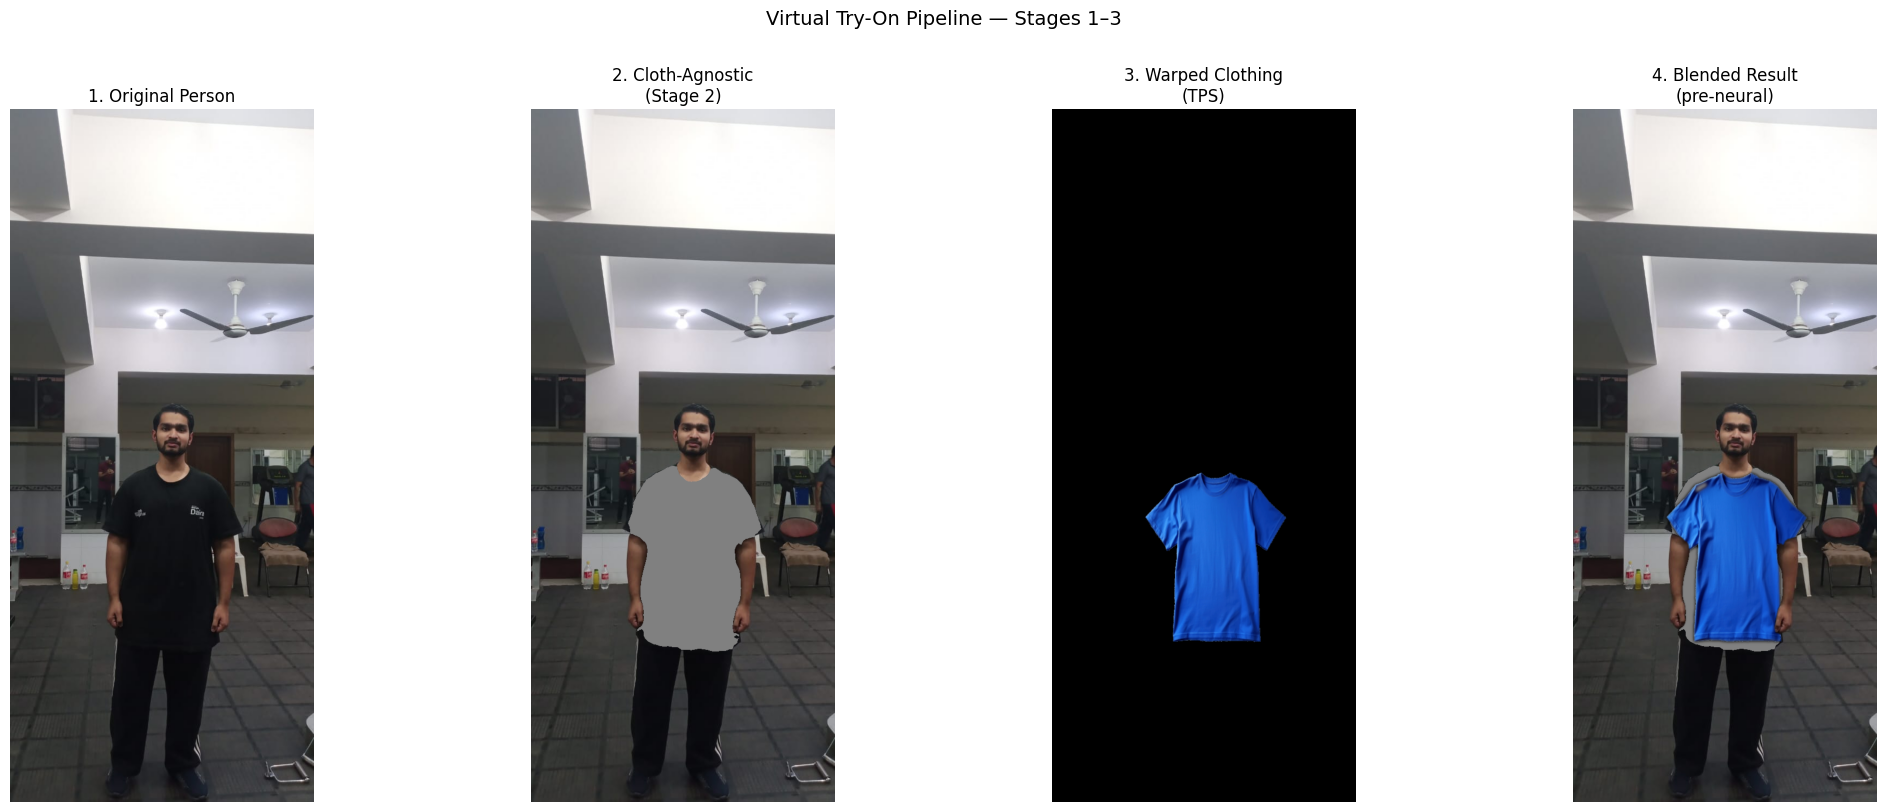

Stage 3 complete!

Files saved to Drive:
  OK warped_clothing.png
  OK warped_mask.png
  OK stage3_blended.png
  OK stage3_pipeline.jpg

Next: Stage 4 — neural try-on synthesis for realistic results.


In [41]:
fig, axes = plt.subplots(1, 4, figsize=(22, 8))

axes[0].imshow(image_rgb)
axes[0].set_title('1. Original Person', fontsize=12)
axes[0].axis('off')

axes[1].imshow(agnostic_rgb)
axes[1].set_title('2. Cloth-Agnostic\n(Stage 2)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(warped_cloth)
axes[2].set_title('3. Warped Clothing\n(TPS)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(blended)
axes[3].set_title('4. Blended Result\n(pre-neural)', fontsize=12)
axes[3].axis('off')

plt.suptitle('Virtual Try-On Pipeline — Stages 1–3', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage3_pipeline.jpg'), dpi=150, bbox_inches='tight')
plt.show()

print("Stage 3 complete!")
print("\nFiles saved to Drive:")
for fname in ['warped_clothing.png', 'warped_mask.png', 'stage3_blended.png', 'stage3_pipeline.jpg']:
    p = os.path.join(OUTPUT_DIR, fname)
    print(f"  {'OK' if os.path.exists(p) else 'MISSING'} {fname}")

print("\nNext: Stage 4 — neural try-on synthesis for realistic results.")

---
## What we learned in Stage 3

- **TPS warping** deforms a flat garment image to match body geometry using control point pairs
- **Coarse placement first** (scale to torso box) makes TPS more stable — less work for the warp
- **Alpha compositing** gives a rough try-on but lacks realism (no shadows, no fabric physics)

### What's missing (solved in Stage 4):
| Problem | Stage 4 solution |
|---|---|
| Hard garment edges | Neural blending with soft boundaries |
| No fabric wrinkles | GAN learns wrinkle patterns from training data |
| Arm/garment layering | Separate arm mask composited on top |
| Lighting mismatch | GAN normalizes illumination |

### The full conditioning inputs we've built:
```
agnostic_person.png  +  warped_clothing.png  +  pose skeleton
         ↓
    [Stage 4: Try-On GAN]
         ↓
    Photorealistic output
```